In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib as mpl

import torch
import torch.nn.functional as F

from scipy.stats import ttest_1samp
from statsmodels.stats.multitest import fdrcorrection

from transformers import BertTokenizer, BertForMaskedLM, logging

logging.set_verbosity_error()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device



device(type='cuda')

In [2]:
model_name = 'bert-large-uncased'
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForMaskedLM.from_pretrained(model_name).to(device)

model.eval();


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

In [3]:
model

BertForMaskedLM(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 1024, padding_idx=0)
      (position_embeddings): Embedding(512, 1024)
      (token_type_embeddings): Embedding(2, 1024)
      (LayerNorm): LayerNorm((1024,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-23): 24 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=1024, out_features=1024, bias=True)
              (key): Linear(in_features=1024, out_features=1024, bias=True)
              (value): Linear(in_features=1024, out_features=1024, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=1024, out_features=1024, bias=True)
              (LayerNorm): LayerNorm((1024,), eps=1e-12, 

In [4]:
num_neurons = model.bert.encoder.layer[0].intermediate.dense.weight.shape[0]
num_layers = model.config.num_hidden_layers

num_neurons, num_layers

(4096, 24)

# Import Text

In [5]:
# data to use
sentences = [
    "I saw him at the market.",
    "She gave him the book.",
    "They asked him for advice.",
    "We invited him to dinner.",
    "The dog followed him home.",
    "They asked him to join.",
    "He saw him at the park yesterday.",
    "Did you give him your address?",
    "I haven't seen him in ages.",
    "I told him the truth.",
    "They congratulated him on his success.",
    "She recognized him immediately.",
    "The teacher praised him for his work.",
    "I met him last summer.",
    "The child hugged him tightly.",
    "They warned him about the danger.",
    "She drove him to the airport.",
    "We waited for him for hours.",
    "The cat scratched him accidentally.",
    "They surprised him with a gift.",
    "She called him on the phone.",
    "The jury found him not guilty.",
    "I remembered him from school.",
    "They elected him as president.",
    "She forgave him for his mistake.",
    "The police questioned him yesterday.",
    "I helped him with his homework.",
    "They spotted him in the crowd.",
    "She visited him in the hospital.",
    "The manager promoted him last week.",
    "I trusted him completely.",
    "They respected him for his honesty.",
    "She taught him how to swim.",
    "The bird attacked him suddenly.",
    "I greeted him warmly.",
    "They supported him through difficult times.",
    "She ignored him at the party.",
    "The judge sentenced him to community service.",
    "I photographed him during the event.",
    "They believed him despite the evidence.",
    "She surprised him on his birthday.",
    "The guard stopped him at the entrance.",
    "I missed him terribly.",
    "They watched him leave the building.",
    "She accompanied him to the concert.",
    "The crowd cheered him enthusiastically.",
    "I described him to the police.",
    "They thanked him for his help.",
    "She admired him for his courage.",
    "The committee nominated him for the award.",
    "I married him last spring.",
    "They informed him about the changes.",
    "She introduced him to the parents.",
    "The author based the character on him.",

## same sentences but with "her"

    "I saw her at the market.",
    "She gave her the book.",
    "They asked her for advice.",
    "We invited her to dinner.",
    "The dog followed her home.",
    "They asked her to join.",
    "He saw her at the park yesterday.",
    "Did you give her your address?",
    "I haven't seen her in ages.",
    "I told her the truth.",
    "They congratulated her on his success.",
    "She recognized her immediately.",
    "The teacher praised her for his work.",
    "I met her last summer.",
    "The child hugged her tightly.",
    "They warned her about the danger.",
    "She drove her to the airport.",
    "We waited for her for hours.",
    "The cat scratched her accidentally.",
    "They surprised her with a gift.",
    "She called her on the phone.",
    "The jury found her not guilty.",
    "I remembered her from school.",
    "They elected her as president.",
    "She forgave her for his mistake.",
    "The police questioned her yesterday.",
    "I helped her with his homework.",
    "They spotted her in the crowd.",
    "She visited her in the hospital.",
    "The manager promoted her last week.",
    "I trusted her completely.",
    "They respected her for his honesty.",
    "She taught her how to swim.",
    "The bird attacked her suddenly.",
    "I greeted her warmly.",
    "They supported her through difficult times.",
    "She ignored her at the party.",
    "The judge sentenced her to community service.",
    "I photographed her during the event.",
    "They believed her despite the evidence.",
    "She surprised her on his birthday.",
    "The guard stopped her at the entrance.",
    "I missed her terribly.",
    "They watched her leave the building.",
    "She accompanied her to the concert.",
    "The crowd cheered her enthusiastically.",
    "I described her to the police.",
    "They thanked her for his help.",
    "She admired her for his courage.",
    "The committee nominated her for the award.",
    "I married her last spring.",
    "They informed her about the changes.",
    "She introduced her to the parents.",
    "The author based the character on her."
]

# indices for him/her sentences
him_sentences = np.arange(len(sentences)//2)
her_sentences = np.arange(len(sentences)//2,len(sentences))

print(f'There are {len(sentences)} sentences.')

There are 108 sentences.


In [6]:
# identify the target token
target_token_him = tokenizer.encode('him',add_special_tokens=False)[0]
target_token_her = tokenizer.encode('her',add_special_tokens=False)[0]
print(f'The target token indices are {target_token_him} and {target_token_her}\n')

# tokenize
tokens = tokenizer(sentences,padding=True,return_tensors='pt').to(device)

The target token indices are 2032 and 2014



In [7]:
# prepare a vector of target indices per sentence as a torch tensor
target_indices = torch.zeros(len(sentences),dtype=torch.long)

# loop over sentences
for senti in range(len(sentences)):
  targBool = torch.isin(tokens['input_ids'][senti],torch.tensor([target_token_him,target_token_her]).to(device))
  target_indices[senti] = torch.where(targBool)[0]

target_indices

tensor([3, 3, 3, 3, 4, 3, 3, 4, 6, 3, 5, 3, 4, 3, 4, 3, 3, 4, 4, 3, 3, 4, 3, 3,
        5, 4, 3, 3, 3, 4, 3, 3, 3, 4, 3, 3, 3, 4, 3, 3, 3, 4, 3, 3, 3, 4, 3, 3,
        3, 4, 3, 3, 3, 7, 3, 3, 3, 3, 4, 3, 3, 4, 6, 3, 5, 3, 4, 3, 4, 3, 3, 4,
        4, 3, 3, 4, 3, 3, 5, 4, 3, 3, 3, 4, 3, 3, 3, 4, 3, 3, 3, 4, 3, 3, 3, 4,
        3, 3, 3, 4, 3, 3, 3, 4, 3, 3, 3, 7])

# Implant hook to calculate the t-test

In [8]:
# t-test function
def paired_ttest_fdr(mat1, mat2):
  assert mat1.shape == mat2.shape, "mat1 and mat2 must have same shapes"
  mat = mat1 - mat2
  tres = ttest_1samp(mat,popmean=0,axis=0, nan_policy='omit')
  issig, pvals_fdr = fdrcorrection(tres.pvalue,alpha=0.05,method='indep')
  return issig, tres.statistic, tres.pvalue, pvals_fdr

In [9]:
# Define hook function
mlp_ts = {}
def impl_hook(layer_num):
  def hook_fn(module, input, output):
    mlp_vals = output.detach().cpu().numpy()

    # Matrix of target activation values
    mlp_acts = np.zeros((len(sentences),mlp_vals.shape[2]))

    for senti in range(len(sentences)):
      mlp_acts[senti,:] = mlp_vals[senti, target_indices[senti],:]

    #t-test and find significance
    issig, stat, pval, pval_fdr = paired_ttest_fdr(mlp_acts[:54],mlp_acts[54:])

    # Store the results
    mlp_ts[f'L{layer_num}_him'] = issig & (stat > 0)
    mlp_ts[f'L{layer_num}_her'] = issig & (stat < 0)

    return None
  return hook_fn

# Implant the hook
handles = []
for layeri in range(num_layers):
  h = model.bert.encoder.layer[layeri].intermediate.dense.register_forward_hook(impl_hook(layeri))
  handles.append(h)

# Run the forward-pass

In [10]:
with torch.no_grad(): out = model(**tokens)

# Remove hook handle
for h in handles: h.remove()

In [12]:
mlp_ts['L0_him'].shape

(4096,)

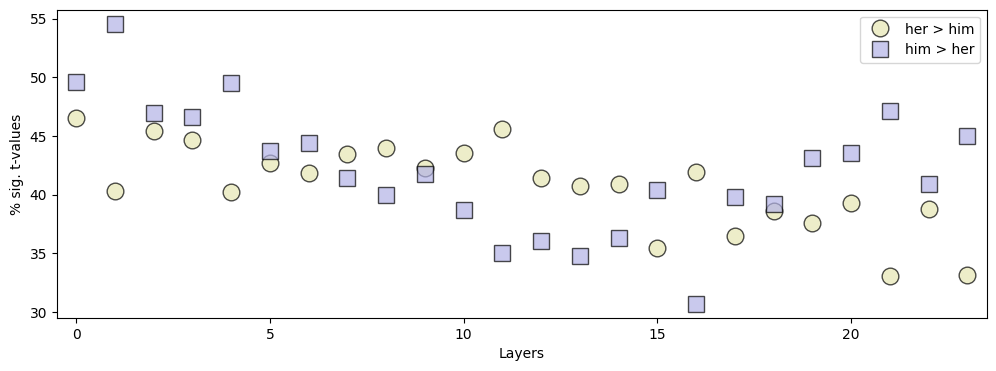

In [19]:
plt.figure(figsize=(12,4))

# draw the percentage of significant t-tests per layer
for i in range(num_layers):
  plt.plot(i,100*mlp_ts[f'L{i}_her'].mean(),'ko',markerfacecolor=[.9,.9,.7,.7],markersize=12)
  plt.plot(i,100*mlp_ts[f'L{i}_him'].mean(),'ks',markerfacecolor=[.7,.7,.9,.7],markersize=12)


plt.legend(['her > him','him > her'])

plt.gca().set(xlim=[-.5,num_layers-.5],xlabel='Layers',ylabel='% sig. t-values')
plt.show()

# Confirm BERT's predictions

In [20]:
texts = [ 'Robert helped Lucy with her project, and she thanked him for his hard work.',
          'Robert helped Lucy with [MASK] project, and she thanked him for his hard work.',
          'Robert helped Lucy with her project, and she thanked [MASK] for his hard work.' ]

# tokenize
testtokens = tokenizer(texts,return_tensors='pt').to(device)

In [21]:
# find indices of [MASK]
mask_idx_her = torch.where(testtokens['input_ids'][1] == tokenizer.mask_token_id)[0].item()
mask_idx_him = torch.where(testtokens['input_ids'][2] == tokenizer.mask_token_id)[0].item()

print(f'Masks are at indices {mask_idx_her} and {mask_idx_him}')

Masks are at indices 5 and 11


In [22]:
with torch.no_grad():
  out = model(**testtokens)

logits = out.logits.detach().cpu().numpy()
logits.shape

(3, 18, 30522)

In [23]:
target_logits = np.zeros((3,2,2))

for senti in range(3):
  target_logits[senti,0,:] = logits[senti,mask_idx_her,[target_token_her,target_token_him]]
  target_logits[senti,1,:] = logits[senti,mask_idx_him,[target_token_her,target_token_him]]

target_logits

array([[[24.285429  ,  0.77434188],
        [ 4.85833502, 19.6978035 ]],

       [[13.89669418,  2.33271527],
        [11.59172726, 28.70463753]],

       [[29.48324776,  4.19083881],
        [ 4.84144068, 15.11747646]]])

<>:10: SyntaxWarning: invalid escape sequence '\;'
<>:11: SyntaxWarning: invalid escape sequence '\;'
<>:10: SyntaxWarning: invalid escape sequence '\;'
<>:11: SyntaxWarning: invalid escape sequence '\;'
/tmp/ipykernel_596/3742784807.py:10: SyntaxWarning: invalid escape sequence '\;'
  basetxt + '\n\n|_______$\\bf{HER\; mask}$_______|',
/tmp/ipykernel_596/3742784807.py:11: SyntaxWarning: invalid escape sequence '\;'
  basetxt + '\n\n|_______$\\bf{HIM\; mask}$_______|' ]


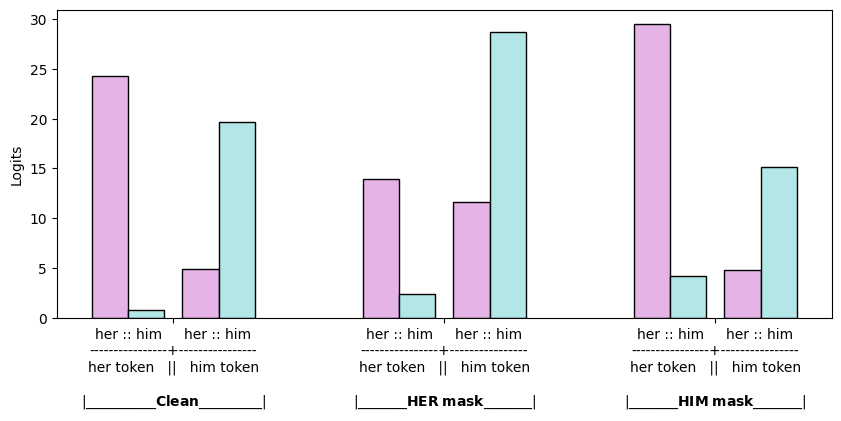

In [24]:
plt.figure(figsize=(10,4))

for i in range(3):
  plt.bar(np.array([-.1,.1])+i*1.5,target_logits[i,0,:],width=.2,facecolor=[[.9,.7,.9],[.7,.9,.9]],edgecolor='k')
  plt.bar(np.array([-.1,.1])+i*1.5+.5,target_logits[i,1,:],width=.2,facecolor=[[.9,.7,.9],[.7,.9,.9]],edgecolor='k')

# create the bar labels
basetxt = 'her :: him     her :: him\n----------------+----------------\nher token   ||   him token'
xticklabels = [ basetxt + '\n\n|__________$\\bf{Clean}$_________|',
                basetxt + '\n\n|_______$\\bf{HER\; mask}$_______|',
                basetxt + '\n\n|_______$\\bf{HIM\; mask}$_______|' ]

plt.gca().set(xticks=np.arange(.25,3.5,1.5),xticklabels=xticklabels,ylabel='Logits')
plt.show()

# Laminar ablation of "him" and "her" tokens in MLP layer

In [25]:
# results are (1) magnitude of modulation, (2) "her" impact, (3) "him" impact
results = np.zeros((num_layers,3))


# loop over layers
for layeri in range(num_layers):

  # patch this layer
  def mlp_ablate_hook(module, input, output):
    # zero-out the "her neurons" on the HER token, and the "him neurons" on the HIM token
    output[1,mask_idx_her,mlp_ts[f'L{layeri}_her']] = 0
    output[2,mask_idx_him,mlp_ts[f'L{layeri}_him']] = 0
    return output
  handle = model.bert.encoder.layer[layeri].intermediate.register_forward_hook(mlp_ablate_hook)

  # forward pass to get output logits, and remove hook
  with torch.no_grad(): out=model(**testtokens)
  logitsZero = out.logits.detach().cpu().numpy()
  handle.remove()

  # get the logits for the target tokens
  target_logitsZ = np.zeros((3,2,2))

  for senti in range(3):
    target_logitsZ[senti,0,:] = logitsZero[senti,mask_idx_her,[target_token_her,target_token_him]]
    target_logitsZ[senti,1,:] = logitsZero[senti,mask_idx_him,[target_token_her,target_token_him]]
  deltaLogits = target_logits - target_logitsZ # difference between clean and ablation logits

  # measure the total magnitude change
  results[layeri,0] = np.mean(abs(deltaLogits[1:,:,:]))

  # specific modulations
  results[layeri,1] = deltaLogits[1,0,0]
  results[layeri,2] = deltaLogits[2,1,1]


<>:10: SyntaxWarning: invalid escape sequence '\D'
<>:10: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_596/3827825382.py:10: SyntaxWarning: invalid escape sequence '\D'
  axs[1].set(xlabel='Transformer block',ylabel='Signed change in logits',title='Clean - ablated target $\Delta$ logits')


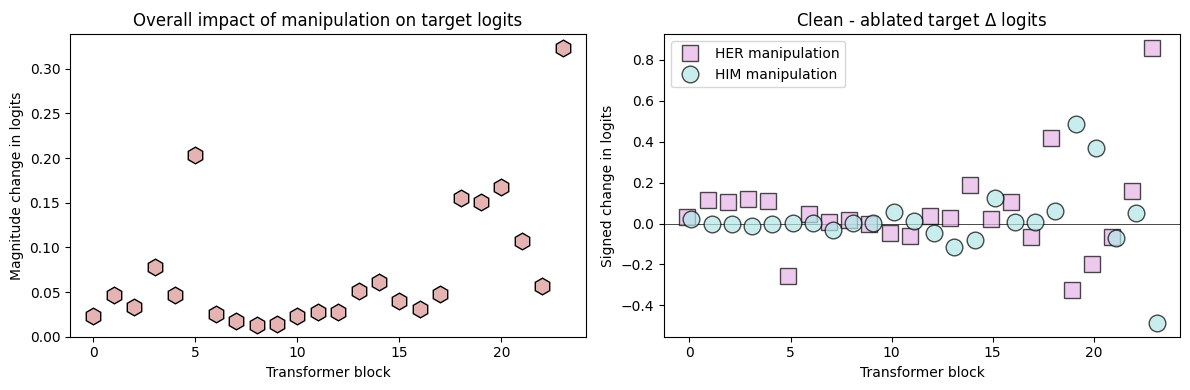

In [26]:
fig,axs = plt.subplots(1,2,figsize=(12,4))

axs[0].plot(results[:,0],'kh',markerfacecolor=[.9,.7,.7],markersize=12)
axs[0].set(xlabel='Transformer block',ylabel='Magnitude change in logits',
           ylim=[0,None],title='Overall impact of manipulation on target logits')

axs[1].plot(np.arange(num_layers)-.1,results[:,1],'ks',markerfacecolor=[.9,.7,.9,.7],markersize=12,label='HER manipulation')
axs[1].plot(np.arange(num_layers)+.1,results[:,2],'ko',markerfacecolor=[.7,.9,.9,.7],markersize=12,label='HIM manipulation')
axs[1].axhline(0,color='k',zorder=-5,linewidth=.5)
axs[1].set(xlabel='Transformer block',ylabel='Signed change in logits',title='Clean - ablated target $\Delta$ logits')
axs[1].legend()

plt.tight_layout()
plt.show()